## Modeling with K-Nearest Neighbors Ball Tree Algorithm for Red Wine Quality Prediction (Classification Problem)

In [49]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

#split Data Train and Test libs
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV

#modeling libs
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score

In [50]:
redwine_df = pd.read_csv('../winequality-red_original_df.csv', sep=';')
redwine_df.sample(5)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
105,8.1,0.575,0.22,2.1,0.077,12.0,65.0,0.9967,3.29,0.51,9.2,5
673,8.2,0.730,0.21,1.7,0.074,5.0,13.0,0.9968,3.20,0.52,9.5,5
523,9.3,0.400,0.49,2.5,0.085,38.0,142.0,0.9978,3.22,0.55,9.4,5
1414,10.0,0.320,0.59,2.2,0.077,3.0,15.0,0.9994,3.20,0.78,9.6,5
559,13.0,0.470,0.49,4.3,0.085,6.0,47.0,1.0021,3.30,0.68,12.7,6


In [51]:
redwine_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


# Simple Descriptive Analysis

In [52]:
redwine_df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


### the scater plot of the data below, describes the relationship between the density and alcohol content of the red wine.
the data shows that the density of the red wine is inversely proportional to the alcohol content. The higher the alcohol content, the lower the density of the red wine.

<Axes: xlabel='density', ylabel='alcohol'>

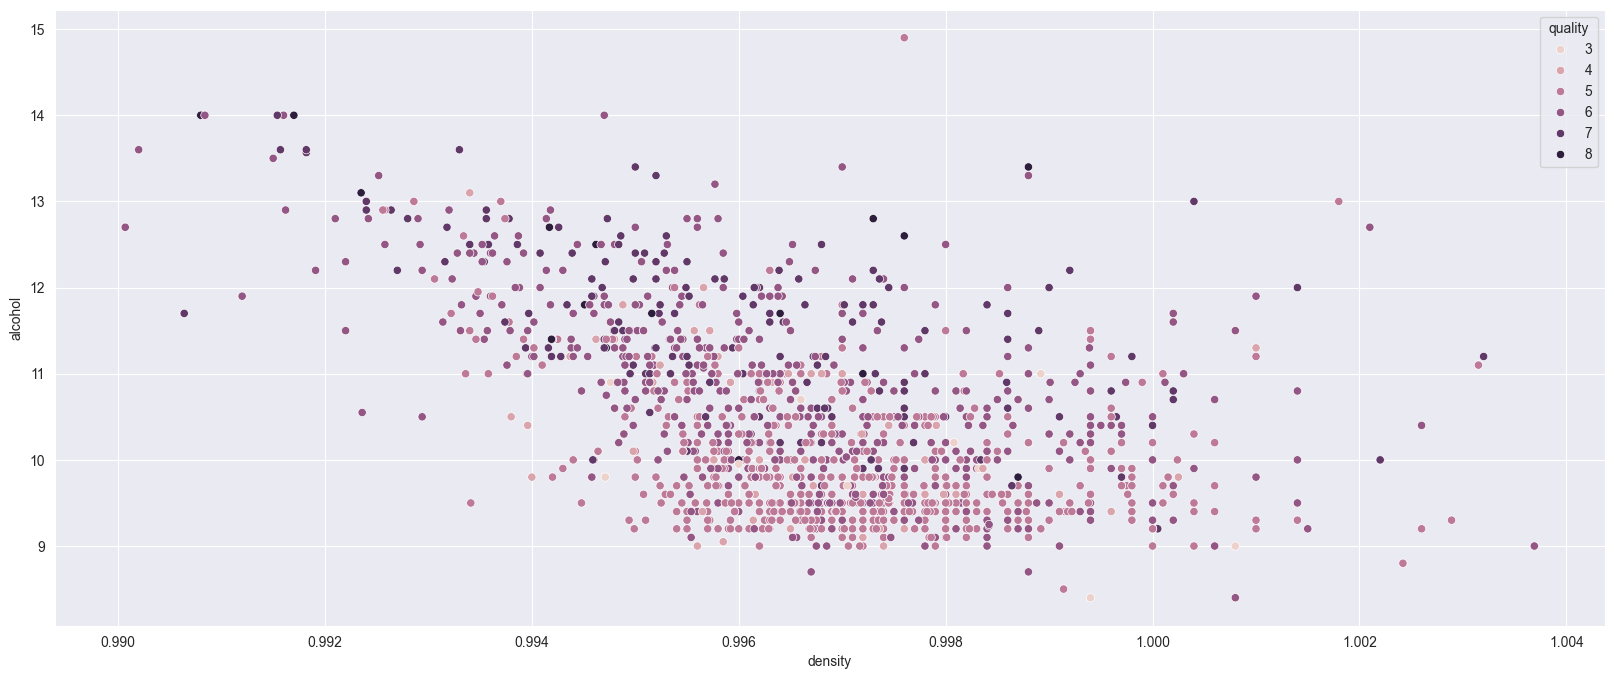

In [53]:
plt.figure(figsize=(20, 8))
sns.scatterplot(x='density', y='alcohol', data= redwine_df, hue='quality')

#Interesting Correlations:

Fixed acidity and pH have a strong negative correlation (-0.68), meaning that as fixed acidity increases, pH decreases.

Alcohol and quality have a moderately positive correlation (0.48), suggesting that higher alcohol content is associated with better quality.

Free sulfur dioxide and total sulfur dioxide have a high positive correlation (0.67), which makes sense since they are related chemically.

Low or Negligible Correlations: Some variables, like chlorides and citric acid, show almost no correlation (0.056), meaning they don’t have a significant linear relationship.

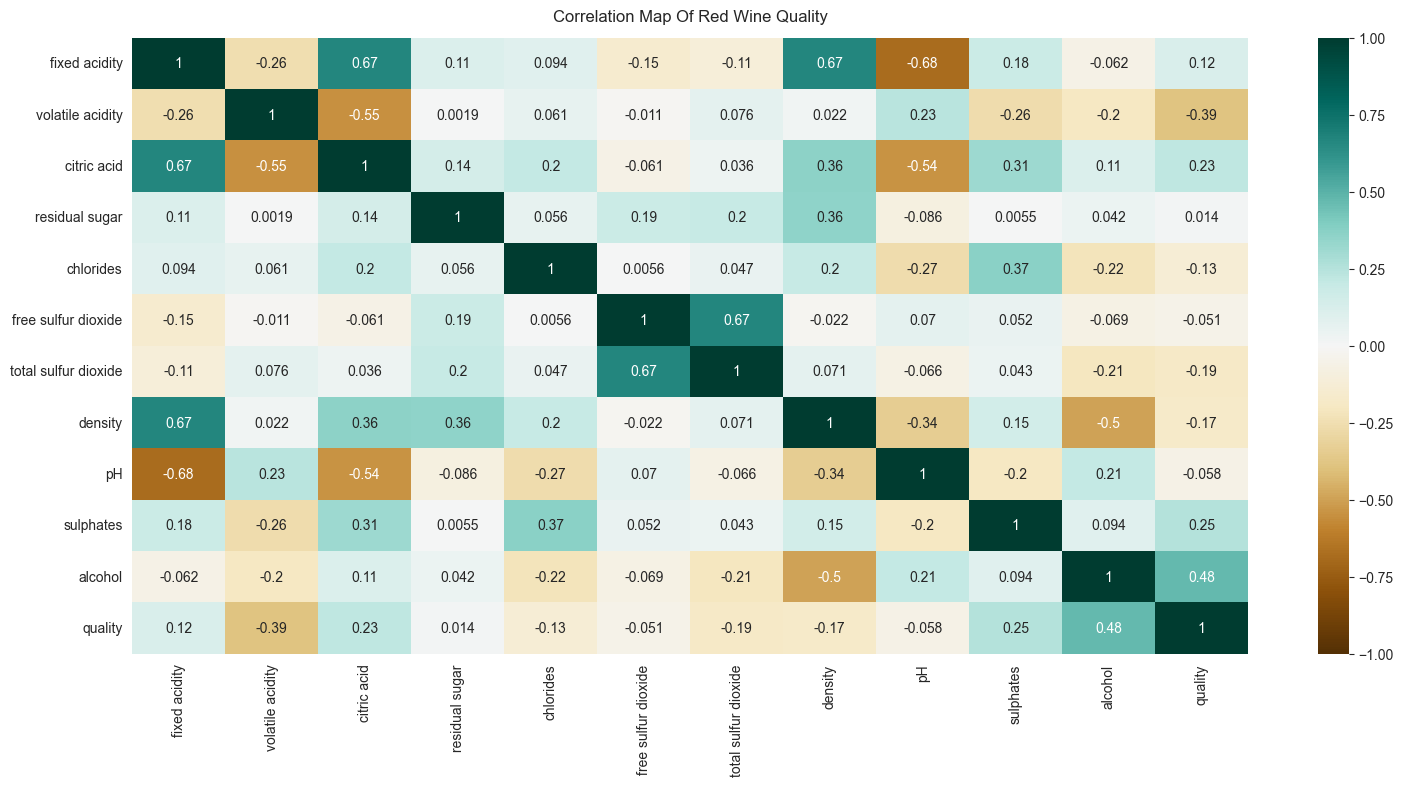

In [54]:
plt.figure(figsize=(18, 8))
sns.heatmap(redwine_df.corr(), vmin=-1, vmax=1, annot=True, cmap='BrBG')
plt.title('Correlation Map Of Red Wine Quality', fontdict={'fontsize':12}, pad=12);

# PreProcessing

In [55]:
redwine_df['quality'].unique()

array([5, 6, 7, 4, 8, 3])

- *If the **quality value > 6**, it means the quality is **good** and I define it as **1**.*
- *If the **quality value < 6,** it means the quality is **bad** and I define it as **0**.*

In [56]:
redwine_df['quality'] = np.where(redwine_df['quality'] > 6, 1, 0)
redwine_df['quality'].value_counts()

quality
0    1382
1     217
Name: count, dtype: int64

In [57]:
redwine_df.sample(50)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
70,7.7,0.630,0.08,1.9,0.076,15.0,27.0,0.99670,3.32,0.54,9.500000,0
658,7.2,0.520,0.07,1.4,0.074,5.0,20.0,0.99730,3.32,0.81,9.600000,0
44,6.8,0.670,0.02,1.8,0.050,5.0,11.0,0.99620,3.48,0.52,9.500000,0
306,7.6,0.620,0.32,2.2,0.082,7.0,54.0,0.99660,3.36,0.52,9.400000,0
27,7.9,0.430,0.21,1.6,0.106,10.0,37.0,0.99660,3.17,0.91,9.500000,0
1565,6.7,0.670,0.02,1.9,0.061,26.0,42.0,0.99489,3.39,0.82,10.900000,0
334,7.9,0.650,0.01,2.5,0.078,17.0,38.0,0.99630,3.34,0.74,11.700000,1
711,8.9,0.565,0.34,3.0,0.093,16.0,112.0,0.99980,3.38,0.61,9.500000,0
482,10.6,0.360,0.59,2.2,0.152,6.0,18.0,0.99860,3.04,1.05,9.400000,0
290,8.7,0.520,0.09,2.5,0.091,20.0,49.0,0.99760,3.34,0.86,10.600000,1


From this actual data, there are **more bad qualities than good ones**. Also indicated that the data is **imbalanced**.

*Splitting Data*

In [58]:
X = redwine_df.drop(['quality'], axis = 1)
y = redwine_df['quality']

In [59]:
X.shape

(1599, 11)

In [60]:
X_train, X_test, y_train, y_test = train_test_split(X,y,
                                                   stratify = y,
                                                   test_size = 0.3,
                                                   random_state = 1111)

## *Find Best K-Score*

A large K value has benefits which include reducing the variance due to the noisy data, the side effect being developing a bias due to which the learner tends to ignore the smaller patterns which may have useful insights. The data indicates underfitting.

In [61]:
k = range(1,50,1)
testing_accuracy = []
training_accuracy = []
score = 0

for i in k:
    knn = KNeighborsClassifier(n_neighbors = i)
    pipe_knn = Pipeline([('scale', MinMaxScaler()), ('knn', knn)])
    pipe_knn.fit(X_train, y_train)
    
    y_pred_train = pipe_knn.predict(X_train)
    training_accuracy.append(accuracy_score(y_train, y_pred_train))
    
    y_pred_test = pipe_knn.predict(X_test)
    acc_score = accuracy_score(y_test,y_pred_test)
    testing_accuracy.append(acc_score)
    
    if score < acc_score:
        score = acc_score
        best_k = i
        
print('Best Accuracy Score', score, 'Best K-Score', best_k)

Best Accuracy Score 0.9083333333333333 Best K-Score 2


# Modeling

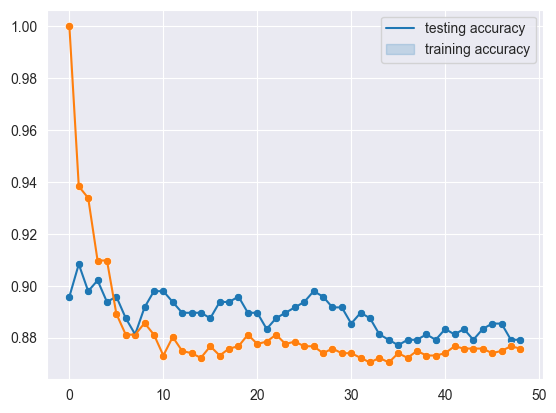

In [62]:
sns.lineplot(testing_accuracy)
sns.scatterplot(testing_accuracy)
sns.lineplot(training_accuracy)
sns.scatterplot(training_accuracy)

plt.legend(['testing accuracy', 'training accuracy'])

*Define Model Using Best K-Score*

In [63]:
knn = KNeighborsClassifier(n_neighbors = 3, weights = 'distance', algorithm='ball_tree')
pipe_knn = Pipeline([('scale', MinMaxScaler()), ('knn', knn)])
pipe_knn.fit(X_train, y_train)

Pipeline(steps=[('scale', MinMaxScaler()),
                ('knn',
                 KNeighborsClassifier(algorithm='ball_tree', n_neighbors=3,
                                      weights='distance'))])

*Cross Validation*

In [64]:
def model_evaluation(model, metric):
    skfold = StratifiedKFold(n_splits = 5)
    model_cv = cross_val_score(model, X_train, y_train, cv = skfold, scoring = metric)
    return model_cv

pipe_knn_cv = model_evaluation(pipe_knn, 'roc_auc')

score_mean = [pipe_knn_cv.mean()]
score_std = [pipe_knn_cv.std()]
score_roc_auc = [roc_auc_score(y_test, pipe_knn.predict(X_test))]
method_name = ['K-Neighbors Classifier']
summary = pd.DataFrame({'method': method_name, 'mean score': score_mean,
                        'std score': score_std, 'roc auc score': score_roc_auc})
summary

,method,mean score,std score,roc auc score
0,K-Neighbors Classifier,0.818884,0.021515,0.809082


Now, see if the HyperParameter Tuning process can boost until getting the maximum score.

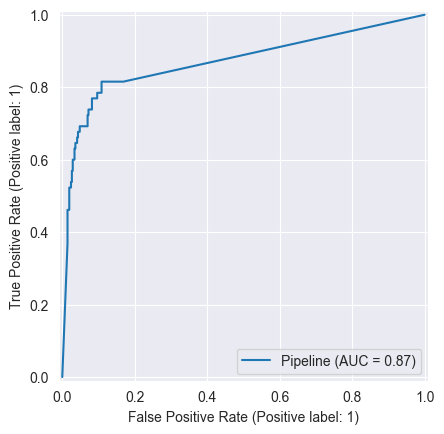

In [65]:
from sklearn.metrics import RocCurveDisplay
RocCurveDisplay.from_estimator(pipe_knn, X_test, y_test)
import matplotlib.pyplot as plt
plt.show()

# HyperParameter Tuning

In [66]:
knn = KNeighborsClassifier(n_neighbors = 3, weights = 'distance', algorithm='ball_tree')
estimator = Pipeline([('scale', MinMaxScaler()), ('knn', knn)])

hyperparam_space = {
    'knn__n_neighbors': [3, 5, 7, 9, 11, 13, 15],
    'knn__leaf_size': [10, 20, 30, 40, 50],
    'knn__weights': ['uniform', 'distance']
}

grid = GridSearchCV(
                estimator,
                param_grid = hyperparam_space,
                cv = StratifiedKFold(n_splits = 5),
                scoring = 'roc_auc',
                n_jobs = -1)

grid.fit(X_train, y_train)

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=None, shuffle=False),
             estimator=Pipeline(steps=[('scale', MinMaxScaler()),
                                       ('knn',
                                        KNeighborsClassifier(algorithm='ball_tree',
                                                             n_neighbors=3,
                                                             weights='distance'))]),
             n_jobs=-1,
             param_grid={'knn__leaf_size': [10, 20, 30, 40, 50],
                         'knn__n_neighbors': [3, 5, 7, 9, 11, 13, 15],
                         'knn__weights': ['uniform', 'distance']},
             scoring='roc_auc')

In [67]:
print('best score', grid.best_score_)
print('best param', grid.best_params_)

best score 0.8828684192841919
best param {'knn__leaf_size': 10, 'knn__n_neighbors': 15, 'knn__weights': 'distance'}


After HyperParameter Tuning, the best score is 0.88616, which getting higher. Leaf size is 10, N neighbors is 17, and Weights is distance. Let's compare the result.

# Before VS After Tuning Comparison

In [68]:
estimator.fit(X_train, y_train)
y_pred_estimator = estimator.predict(X_test)
print(classification_report(y_test, y_pred_estimator))

              precision    recall  f1-score   support

           0       0.95      0.96      0.95       415
           1       0.70      0.66      0.68        65

    accuracy                           0.92       480
   macro avg       0.83      0.81      0.82       480
weighted avg       0.91      0.92      0.92       480



In [69]:
grid.best_estimator_.fit(X_train, y_train)
y_pred_grid = grid.best_estimator_.predict(X_test)
print(classification_report(y_test, y_pred_grid))

              precision    recall  f1-score   support

           0       0.93      0.98      0.95       415
           1       0.77      0.52      0.62        65

    accuracy                           0.91       480
   macro avg       0.85      0.75      0.79       480
weighted avg       0.91      0.91      0.91       480



In [70]:
score_list = [roc_auc_score(y_test, y_pred_estimator), roc_auc_score(y_test, y_pred_grid)]
accuracy = [score, accuracy_score(y_test, y_pred_grid)]
method_name = ['K-Neighbors Classifier Before Tuning', 'K-Neighbors Classifier After Tuning']
best_summary = pd.DataFrame({
    'method': method_name,
    'roc auc score': score_list,
    'accuracy score': accuracy
})
best_summary

,method,roc auc score,accuracy score
0,K-Neighbors Classifier Before Tuning,0.809082,0.908333
1,K-Neighbors Classifier After Tuning,0.749490,0.914583


From this score, I see that the roc auc score after tuning is getting lower, even the accuracy score is getting higher. First thing, the data is imbalanced, so it could cause this, and the second thing is the data indicates underfitting training dataset.

In [71]:
# testing the model on a new datafram

In [96]:
import pandas as pd

# defining the data without the 'quality' column
data = [
    [12.8, 0.3, 0.74, 2.6, 0.095, 9, 28, 0.9994, 3.2, 0.77, 10.8],
    [6.7, 0.62, 0.21, 1.9, 0.079, 8, 62, 0.997, 3.52, 0.58, 9.3],
    [8.9, 0.31, 0.57, 2, 0.111, 26, 85, 0.9971, 3.26, 0.53, 9.7],
    [9.6,0.32,0.47,1.4,0.056,9,24,0.99695,3.22,0.82,10.3]
]

# Define columns without 'quality'
columns = ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 
           'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 
           'alcohol']

# Create the DataFrame
df = pd.DataFrame(data, columns=columns)

# Use the trained pipeline to predict the quality (assuming pipe_knn is already trained)
predictions = pipe_knn.predict(df)

# Display the prediction results
print("Predicted Quality for the new data:")
print(predictions)


Predicted Quality for the new data:
[1 0 0 1]
